# Model Comparison — USGS Streamflow (+ Historical Precipitation)

Trains two spatiotemporal architectures on the Delaware River basin gauges
with historical precipitation as an exogenous covariate.

| Model | Temporal encoder | Spatial encoder |
|---|---|---|
| **DCRNN** | GRU | Diffusion convolution (ChebNet) |
| **GRUGCNModel** | GRU | Graph convolution (GCN) |

Settings: `window=7` days in → `horizon=3` days out, 31 gauges, daily discharge.


## How this notebook works

### What the model does

**Input:** past `window=7` days of discharge **and precipitation** at **all 31 gauges simultaneously**, plus the river graph (which encodes which gauges are upstream of which).  
**Output:** next `horizon=3` days of discharge at **all 31 gauges simultaneously**.

Precipitation enters as an exogenous covariate `u` (shape `(B, window, N, 1)`), scaled independently of the streamflow target.

The `batch_size=16` means 16 **time windows** per gradient step. Every batch always includes all 31 gauges.

### Train / Val / Test split — by time, not by gauge

```
|─────── train (70%) ──────|── val (10%) ──|── test (20%) ──|
Oct 2021                                   Jul 19, 2022    Sep 30, 2022
```

The model is trained on Oct 2021 → ~Jul 2022, validated on the next ~5 weeks, and tested on **Jul 19 – Sep 30** (summer low-flow / storm season).


## 1. Data setup (reused from usgs_streamflow_tsl.ipynb)

In [25]:
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target DataFrame ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)

id_conversion = pd.read_csv(
    os.path.join(os.getcwd(), '../02_Generate_Graph_And_Data_Analysis/site_id_naming_reference.csv'),
    dtype={'site_id': str}
)

rename_map = id_conversion.set_index('site_id')['site_rename'].to_dict()

target = streamflow.rename(columns=rename_map)
target = target[sorted(target.columns, key=lambda x: int(x.replace('site', '')))]
target = target.ffill().bfill()

# --- Exogenous covariate: precipitation ---
precipitation = pd.read_csv(
    os.path.join(DATA_DIR, 'precipitation_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)
precipitation = precipitation.rename(columns=rename_map)
precipitation = precipitation[sorted(precipitation.columns, key=lambda x: int(x.replace('site', '')))]
precipitation = precipitation.ffill().bfill()

# Align to shared dates (in case the two CSVs differ by a day at the boundary)
common_idx    = target.index.intersection(precipitation.index)
target        = target.loc[common_idx]
precipitation = precipitation.loc[common_idx]
print(f'Aligned to {len(common_idx)} shared timesteps')

N_NODES = target.shape[1]
print(f'Target:        {target.shape}')
print(f'Precipitation: {precipitation.shape}')

# --- Connectivity ---
graph_edges_all = [
    ('site0','site2'),('site1','site2'),('site2','site6'),('site3','site6'),
    ('site4','site6'),('site5','site6'),('site6','site8'),('site7','site8'),
    ('site8','site9'),('site9','site11'),('site10','site11'),('site11','site13'),
    ('site12','site13'),('site13','site15'),('site14','site15'),('site15','site17'),
    ('site16','site17'),('site18','site21'),('site19','site20'),('site20','site21'),
    ('site21','site26'),('site22','site26'),('site23','site26'),('site24','site26'),
    ('site25','site26'),('site26','site27'),('site27','site30'),('site28','site29'),
    ('site29','site30'),('site30','site13'),
]
node_to_idx = {f'site{i}': i for i in range(31)}
src = [node_to_idx[u] for u, v in graph_edges_all]
dst = [node_to_idx[v] for u, v in graph_edges_all]
edge_index  = torch.tensor([src, dst], dtype=torch.long)
edge_weight = torch.ones(edge_index.shape[1], dtype=torch.float)
connectivity = (edge_index, edge_weight)

print(f'Graph: {N_NODES} nodes, {edge_index.shape[1]} edges')

Seed set to 42


Aligned to 364 shared timesteps
Target:        (364, 31)
Precipitation: (364, 31)
Graph: 31 nodes, 30 edges


## 2. Shared dataset and datamodule factory

In [26]:
WINDOW  = 7
HORIZON = 3
BATCH   = 16

torch_dataset = SpatioTemporalDataset(
    target=target,
    connectivity=connectivity,
    window=WINDOW,
    horizon=HORIZON,
    stride=1,
)
# Reshape to (T, N, 1) and use pattern 't n f' so each batch yields u: (B, window, N, 1).
# With pattern 't n' the batch would be (B, window, N) — 3D — and DCRNN would misinterpret
# the node axis as a feature/channel axis, causing a shape mismatch in its linear layer.
precip_array = torch.tensor(
    precipitation.values[:, :, np.newaxis], dtype=torch.float32
)  # (T, N, 1)
torch_dataset.add_covariate('u', precip_array, pattern='t n f')

def make_dm():
    """Fresh DataModule with refitted scalers — call once per model run."""
    dm = SpatioTemporalDataModule(
        dataset=torch_dataset,
        scalers={
            'target': StandardScaler(axis=(0, 1)),
            'u':      StandardScaler(axis=(0, 1)),
        },
        splitter=TemporalSplitter(val_len=0.1, test_len=0.2),
        batch_size=BATCH,
        workers=4,
    )
    dm.setup()
    return dm

dm_check = make_dm()
batch = next(iter(dm_check.train_dataloader()))
print('Sample input x :', batch.input.x.shape)   # (B, window, N, 1)
print('Sample input u :', batch.input.u.shape)   # (B, window, N, 1)  — precipitation
print('Sample target y:', batch.y.shape)          # (B, horizon, N, 1)
print('Train / Val / Test batches:',
      len(dm_check.train_dataloader()),
      len(dm_check.val_dataloader()),
      len(dm_check.test_dataloader()))

Sample input x : torch.Size([16, 7, 31, 1])
Sample input u : torch.Size([16, 7, 31, 1])
Sample target y: torch.Size([16, 3, 31, 1])
Train / Val / Test batches: 15 2 5


## 3. Training helper + forecast collection

In [27]:
from pytorch_lightning.callbacks import ModelCheckpoint

def train_and_evaluate(model, name, max_epochs=30):
    """
    Train model, evaluate on test set, and collect forecasts.

    Returns
    -------
    metrics : dict
        test_mae, test_mse, model name, param count
    forecasts : dict
        y_true  : (n_test, N) — step-1 of horizon, inverse-scaled (m³/s)
        y_hat   : (n_test, N) — step-1 of horizon, inverse-scaled (m³/s)
        y_true_h: (n_test, horizon, N) — full horizon, inverse-scaled
        y_hat_h : (n_test, horizon, N) — full horizon, inverse-scaled
        dates   : DatetimeIndex aligned to the first predicted day
        dm      : the fitted DataModule (scaler lives here)
    """
    print(f'\n{"="*60}')
    print(f'  {name}')
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n_params:,}')
    print(f'{"="*60}')

    dm = make_dm()

    predictor = Predictor(
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
    )

    checkpoint_cb = ModelCheckpoint(
        monitor='val_mae',
        mode='min',
        save_top_k=1,
        filename=f'{name}-best',
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='auto',
        devices=1,
        enable_progress_bar=True,
        logger=False,
        callbacks=[checkpoint_cb],
    )

    trainer.fit(predictor, datamodule=dm)
    print(f'  Best val_mae checkpoint: {checkpoint_cb.best_model_path}')

    # Load best weights before test / forecast collection
    predictor = Predictor.load_from_checkpoint(
        checkpoint_cb.best_model_path,
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
        weights_only=False,
    )

    test_metrics = trainer.test(predictor, datamodule=dm, verbose=False)

    # ── Collect raw predictions on the test set ──────────────────────────
    predictor.eval()
    y_true_list, y_hat_list = [], []

    with torch.no_grad():
        for batch in dm.test_dataloader():
            y_hat = predictor.predict_batch(batch, preprocess=False, postprocess=False)
            y_true_list.append(batch.y.cpu())
            y_hat_list.append(y_hat.cpu())

    # Stack → (n_test_samples, horizon, N) — keep as Tensors for inverse_transform
    y_true_all = torch.cat(y_true_list).squeeze(-1)
    y_hat_all  = torch.cat(y_hat_list).squeeze(-1)

    # batch.y comes out of the DataModule in original (m³/s) space — no inverse_transform needed.
    # y_hat from predict_batch(postprocess=False) is in scaled space — inverse_transform it.
    scaler = dm.scalers['target']
    n, h, n_nodes = y_true_all.shape
    y_true_inv = y_true_all.numpy()
    y_hat_inv  = scaler.inverse_transform(
        y_hat_all.reshape(-1, n_nodes)).reshape(n, h, n_nodes).numpy()

    # ── Align predictions to calendar dates ──────────────────────────────
    # For sample at dataset index k, the input window covers rows k … k+WINDOW-1,
    # so the first predicted timestep is row k + WINDOW in target.
    test_indices = dm.test_dataloader().dataset.indices   # integer positions in torch_dataset
    pred_dates   = target.index[[idx + WINDOW for idx in test_indices]]

    forecasts = {
        'y_true'  : y_true_inv[:, 0, :],   # (n_test, N)
        'y_hat'   : y_hat_inv[:, 0, :],    # (n_test, N)
        'y_true_h': y_true_inv,            # (n_test, horizon, N)
        'y_hat_h' : y_hat_inv,             # (n_test, horizon, N)
        'dates'   : pred_dates,
        'dm'      : dm,
    }

    test_metrics[0]['model']    = name
    test_metrics[0]['n_params'] = n_params
    return test_metrics[0], forecasts


## 4. Model A — DCRNN
Diffusion Convolutional Recurrent Neural Network.  
GRU cells with diffusion graph convolution as the spatial mixing step. Strong baseline for directed graphs.

In [28]:
from tsl.nn.models import DCRNNModel

dcrnn = DCRNNModel(
    input_size=1,
    exog_size=1,
    output_size=1,
    horizon=HORIZON,
    hidden_size=32,
    kernel_size=8,
    n_layers=2,
    dropout=0.1,
)

results_dcrnn, forecasts_dcrnn = train_and_evaluate(dcrnn, 'DCRNN')
save_path = os.path.join(FORECASTS_DIR, 'dcrnn_forecasts_rain.pt')
torch.save(forecasts_dcrnn, save_path)
print(f'DCRNN forecasts saved to: {save_path}')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



  DCRNN
  Trainable parameters: 220,515


/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/src/03_TorchSpatiotemporal/checkpoints exists and is not empty.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE        | 0      | train | 0    
1 | train_metrics | MetricCollection | 0      | train | 0    
2 | val_metrics   | MetricCollection | 0      | train | 0    
3 | test_metrics  | MetricCollection | 0      | train | 0    
4 | model         | DCRNNModel       | 220 K  | train | 0    
-------------------------------------------------------------------
220 K     Trainable params
0         Non-trainable params
220 K     Total params
0.882     Total estimated model params size (MB)
49        Modules in train mode
0         Modules in eval mode
0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


...

Testing DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]

Only args ['edge_weight', 'u', 'edge_index', 'x'] are forwarded to the model (DCRNNModel).


Testing DataLoader 0:  20%|██        | 1/5 [00:00<00:01,  2.43it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Testing DataLoader 0: 100%|██████████| 5/5 [00:01<00:00,  3.22it/s]
DCRNN forecasts saved to: /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/data/forecast/dcrnn_forecasts_rain.pt


## 5. Model B — GRUGCNModel
GRU encoder followed by a GCN layer for spatial aggregation.  
Simpler than DCRNN — GRU and GCN are decoupled rather than interleaved.

In [29]:
from tsl.nn.models import GRUGCNModel

grugcn = GRUGCNModel(
    input_size=1,
    hidden_size=32,
    output_size=1,
    horizon=HORIZON,
    exog_size=1,
    enc_layers=2,
    gcn_layers=8,
)

results_grugcn, forecasts_grugcn = train_and_evaluate(grugcn, 'GRUGCNModel')
save_path = os.path.join(FORECASTS_DIR, 'grugcn_forecasts_rain.pt')
torch.save(forecasts_grugcn, save_path)
print(f'GRUGCNModel forecasts saved to: {save_path}')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/src/03_TorchSpatiotemporal/checkpoints exists and is not empty.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE        | 0      | train | 0    
1 | train_metrics | MetricCollection | 0      | train | 0    
2 | val_metrics   | MetricCollection | 0      | train | 0    
3 | test_metrics  | MetricCollection | 0      | train | 0    
4 | model      


  GRUGCNModel
  Trainable parameters: 20,451
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

Only args ['edge_weight', 'u', 'edge_index', 'x'] are forwarded to the model (GRUGCNModel).


...

Testing DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]

Only args ['edge_weight', 'u', 'edge_index', 'x'] are forwarded to the model (GRUGCNModel).


Testing DataLoader 0: 100%|██████████| 5/5 [00:00<00:00, 32.15it/s]


/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


GRUGCNModel forecasts saved to: /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/data/forecast/grugcn_forecasts_rain.pt


## 6. Results comparison

In [30]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target DataFrame ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)


# ── Load forecasts from disk ─────────────────────────────────────────────
# Use this block when restarting the kernel to skip retraining.
MODEL_FILES = {
    'DCRNN':            'dcrnn_forecasts_rain.pt',
    'GRUGCNModel':      'grugcn_forecasts_rain.pt',
}

all_forecasts = {}
all_results   = []

for name, fname in MODEL_FILES.items():
    fpath = os.path.join(FORECASTS_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Missing: {fpath} — run the training cells first')
        continue
    fc = torch.load(fpath, weights_only=False)
    all_forecasts[name] = fc
    # Recompute MAE/MSE from saved arrays (original m³/s space)
    mae = float(np.abs(fc['y_true'] - fc['y_hat']).mean())
    mse = float(((fc['y_true'] - fc['y_hat']) ** 2).mean())
    all_results.append({'model': name, 'test_mae': mae, 'test_mse': mse, 'n_params': None})
    print(f'Loaded {name}  MAE={mae:.3f} m³/s  MSE={mse:.3f}')

df_results = pd.DataFrame(all_results).set_index('model')
df_results.columns = [c.replace('test_', '') for c in df_results.columns]
print()
print(df_results[['mae', 'mse', 'n_params']].to_string())

Seed set to 42


Loaded DCRNN  MAE=2.188 m³/s  MSE=57.221
Loaded GRUGCNModel  MAE=1.914 m³/s  MSE=75.729

                  mae        mse n_params
model                                    
DCRNN        2.188087  57.221050     None
GRUGCNModel  1.914390  75.728539     None


/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/torch/serialization.py:2190: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  result = unpickler.load()


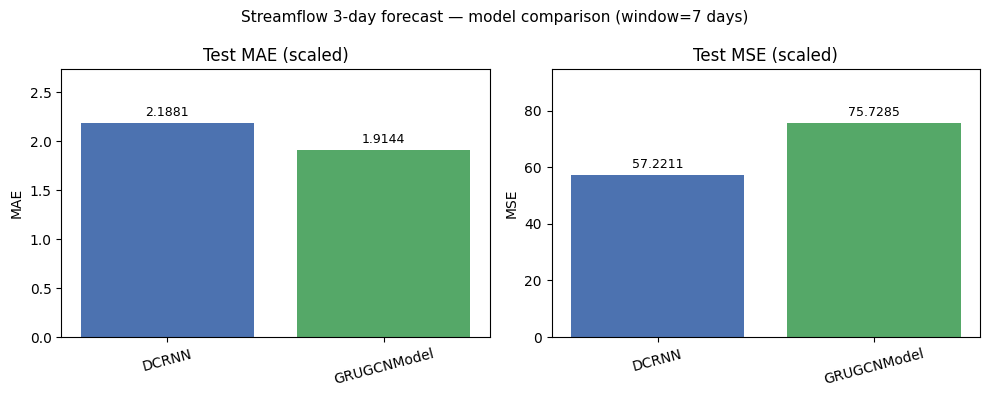

In [31]:
# ── MAE / MSE bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = df_results.index.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['mae', 'mse']):
    bars = ax.bar(models, df_results[metric], color=colors)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(f'Test {metric.upper()} (scaled)')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, df_results[metric].max() * 1.25)

plt.suptitle('Streamflow 3-day forecast — model comparison (window=7 days)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. All-gauge forecast plots

For each model: a grid showing all 31 gauges. Each subplot has:
- **Grey** — observed discharge in the 30 days before the test period (context)
- **Black** — observed discharge during the test period (ground truth)
- **Coloured** — model forecast (step-1 of horizon, i.e. next-day prediction)

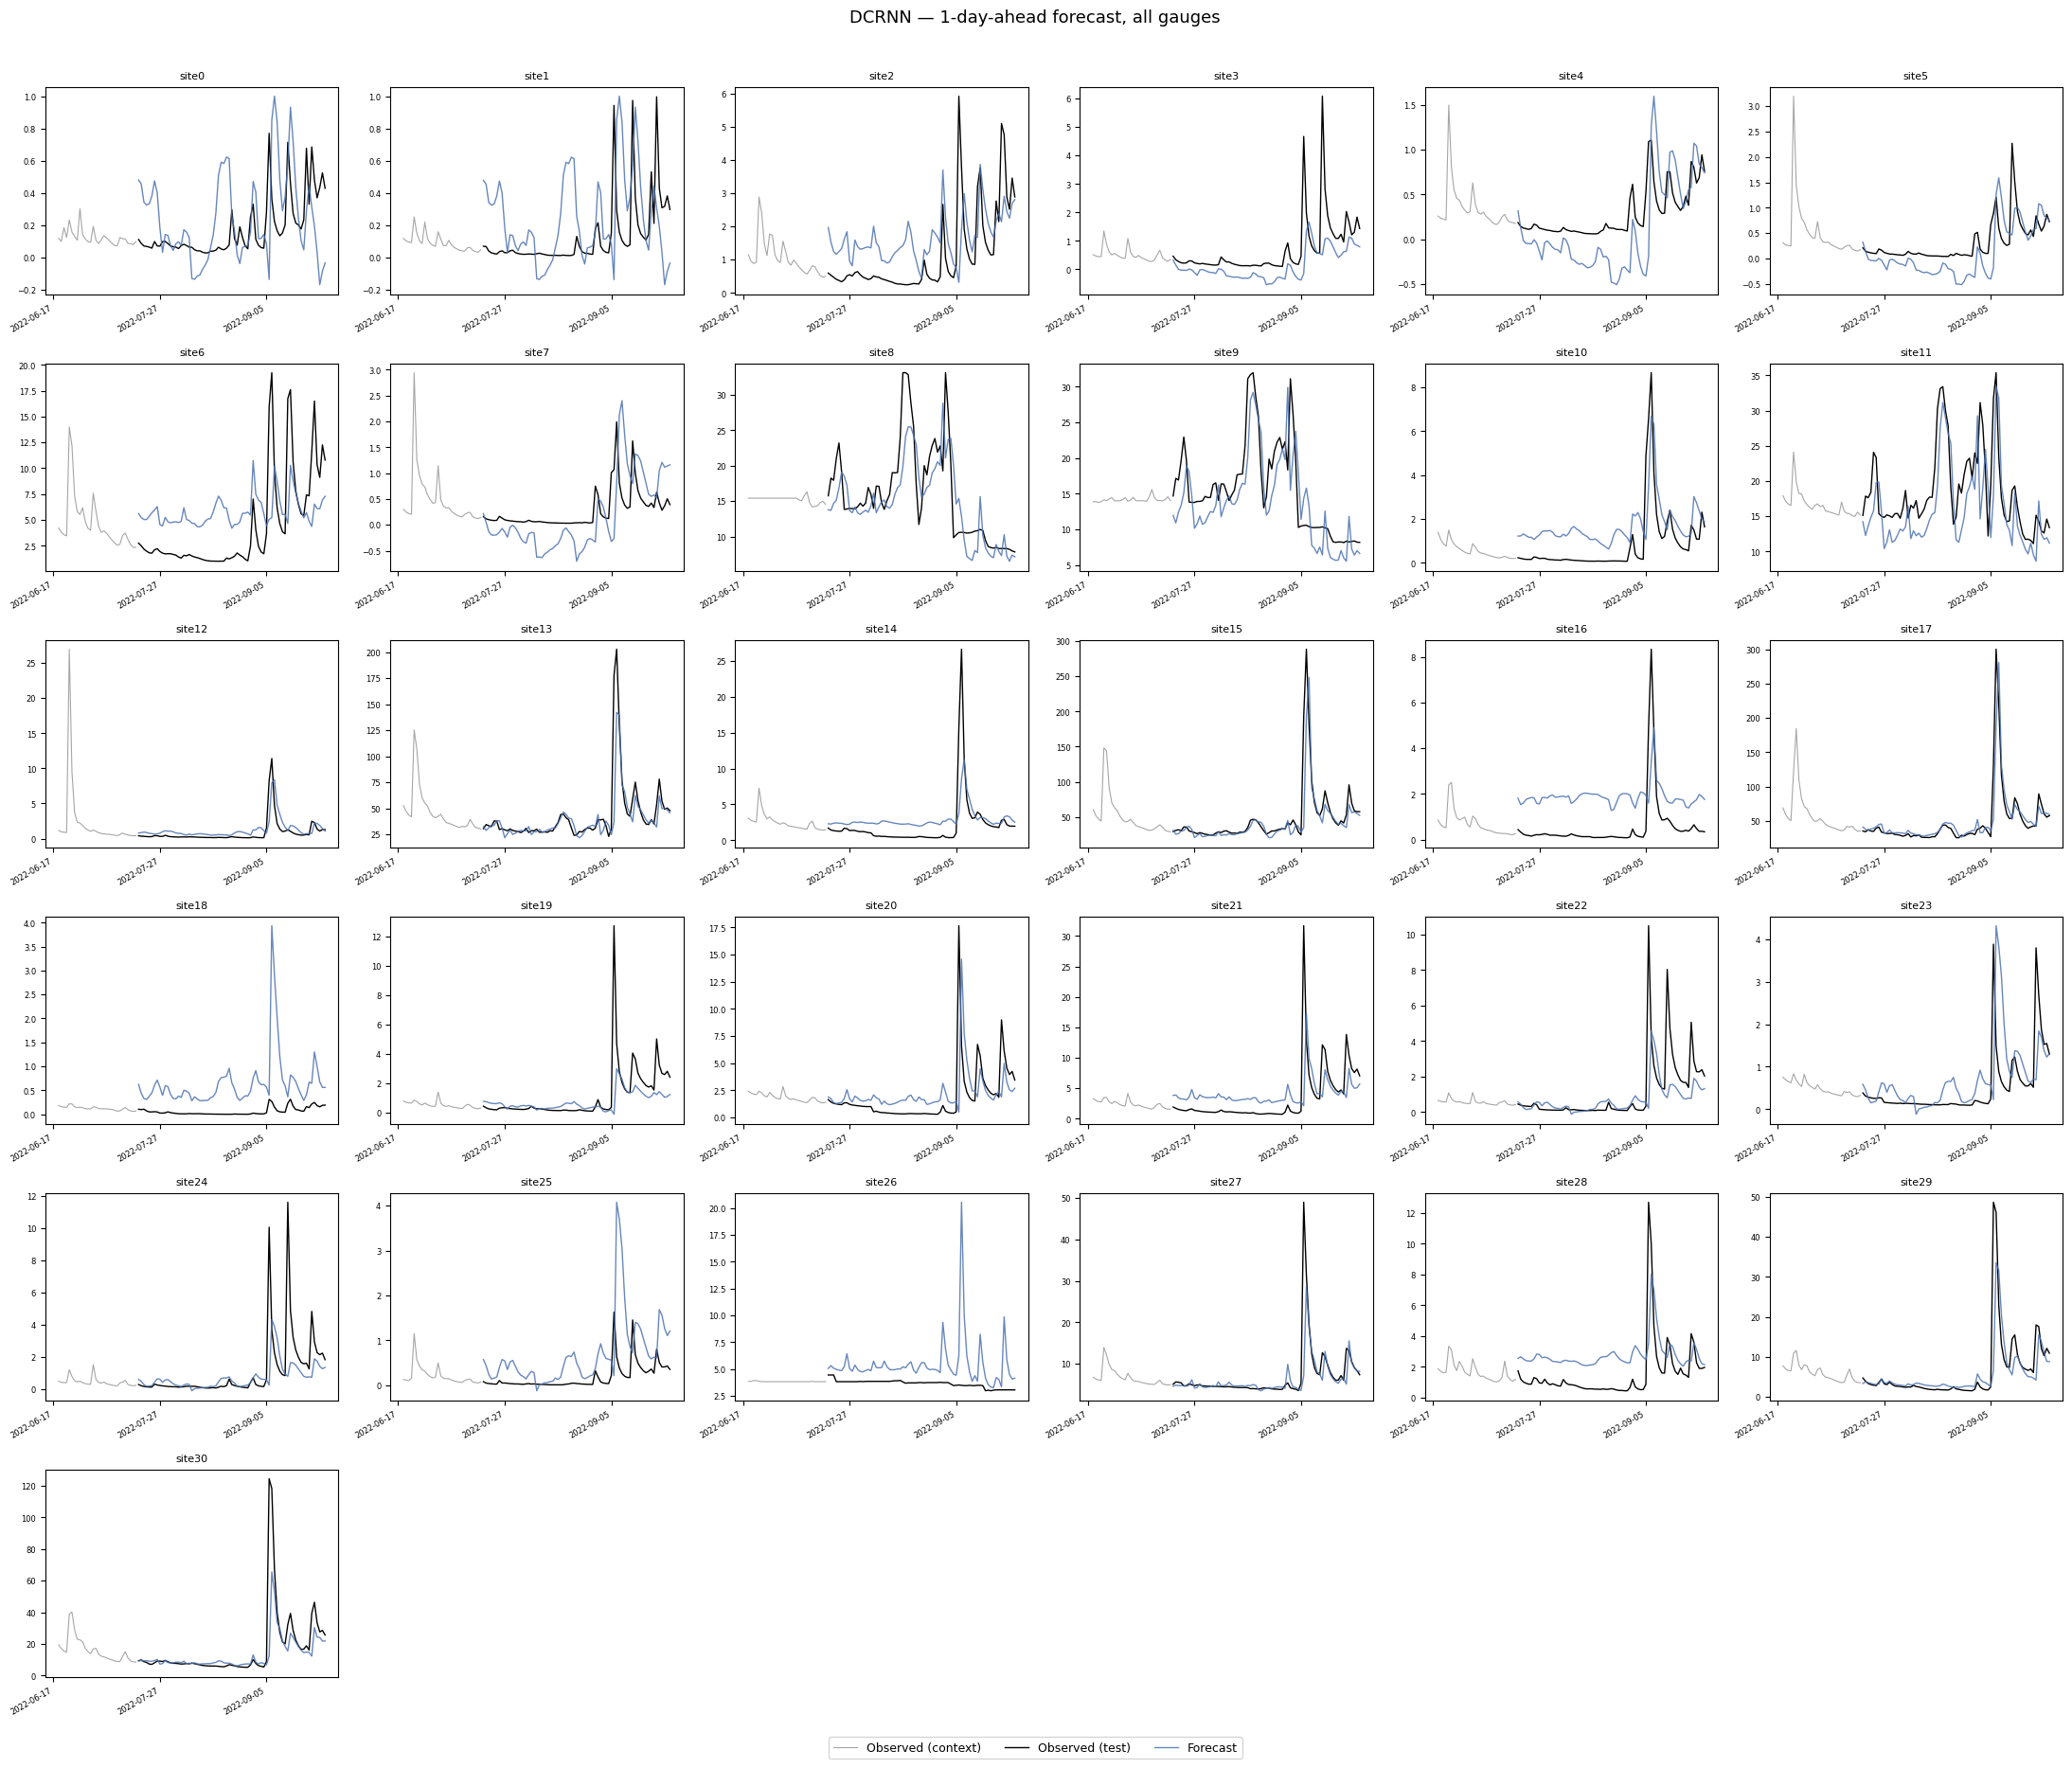

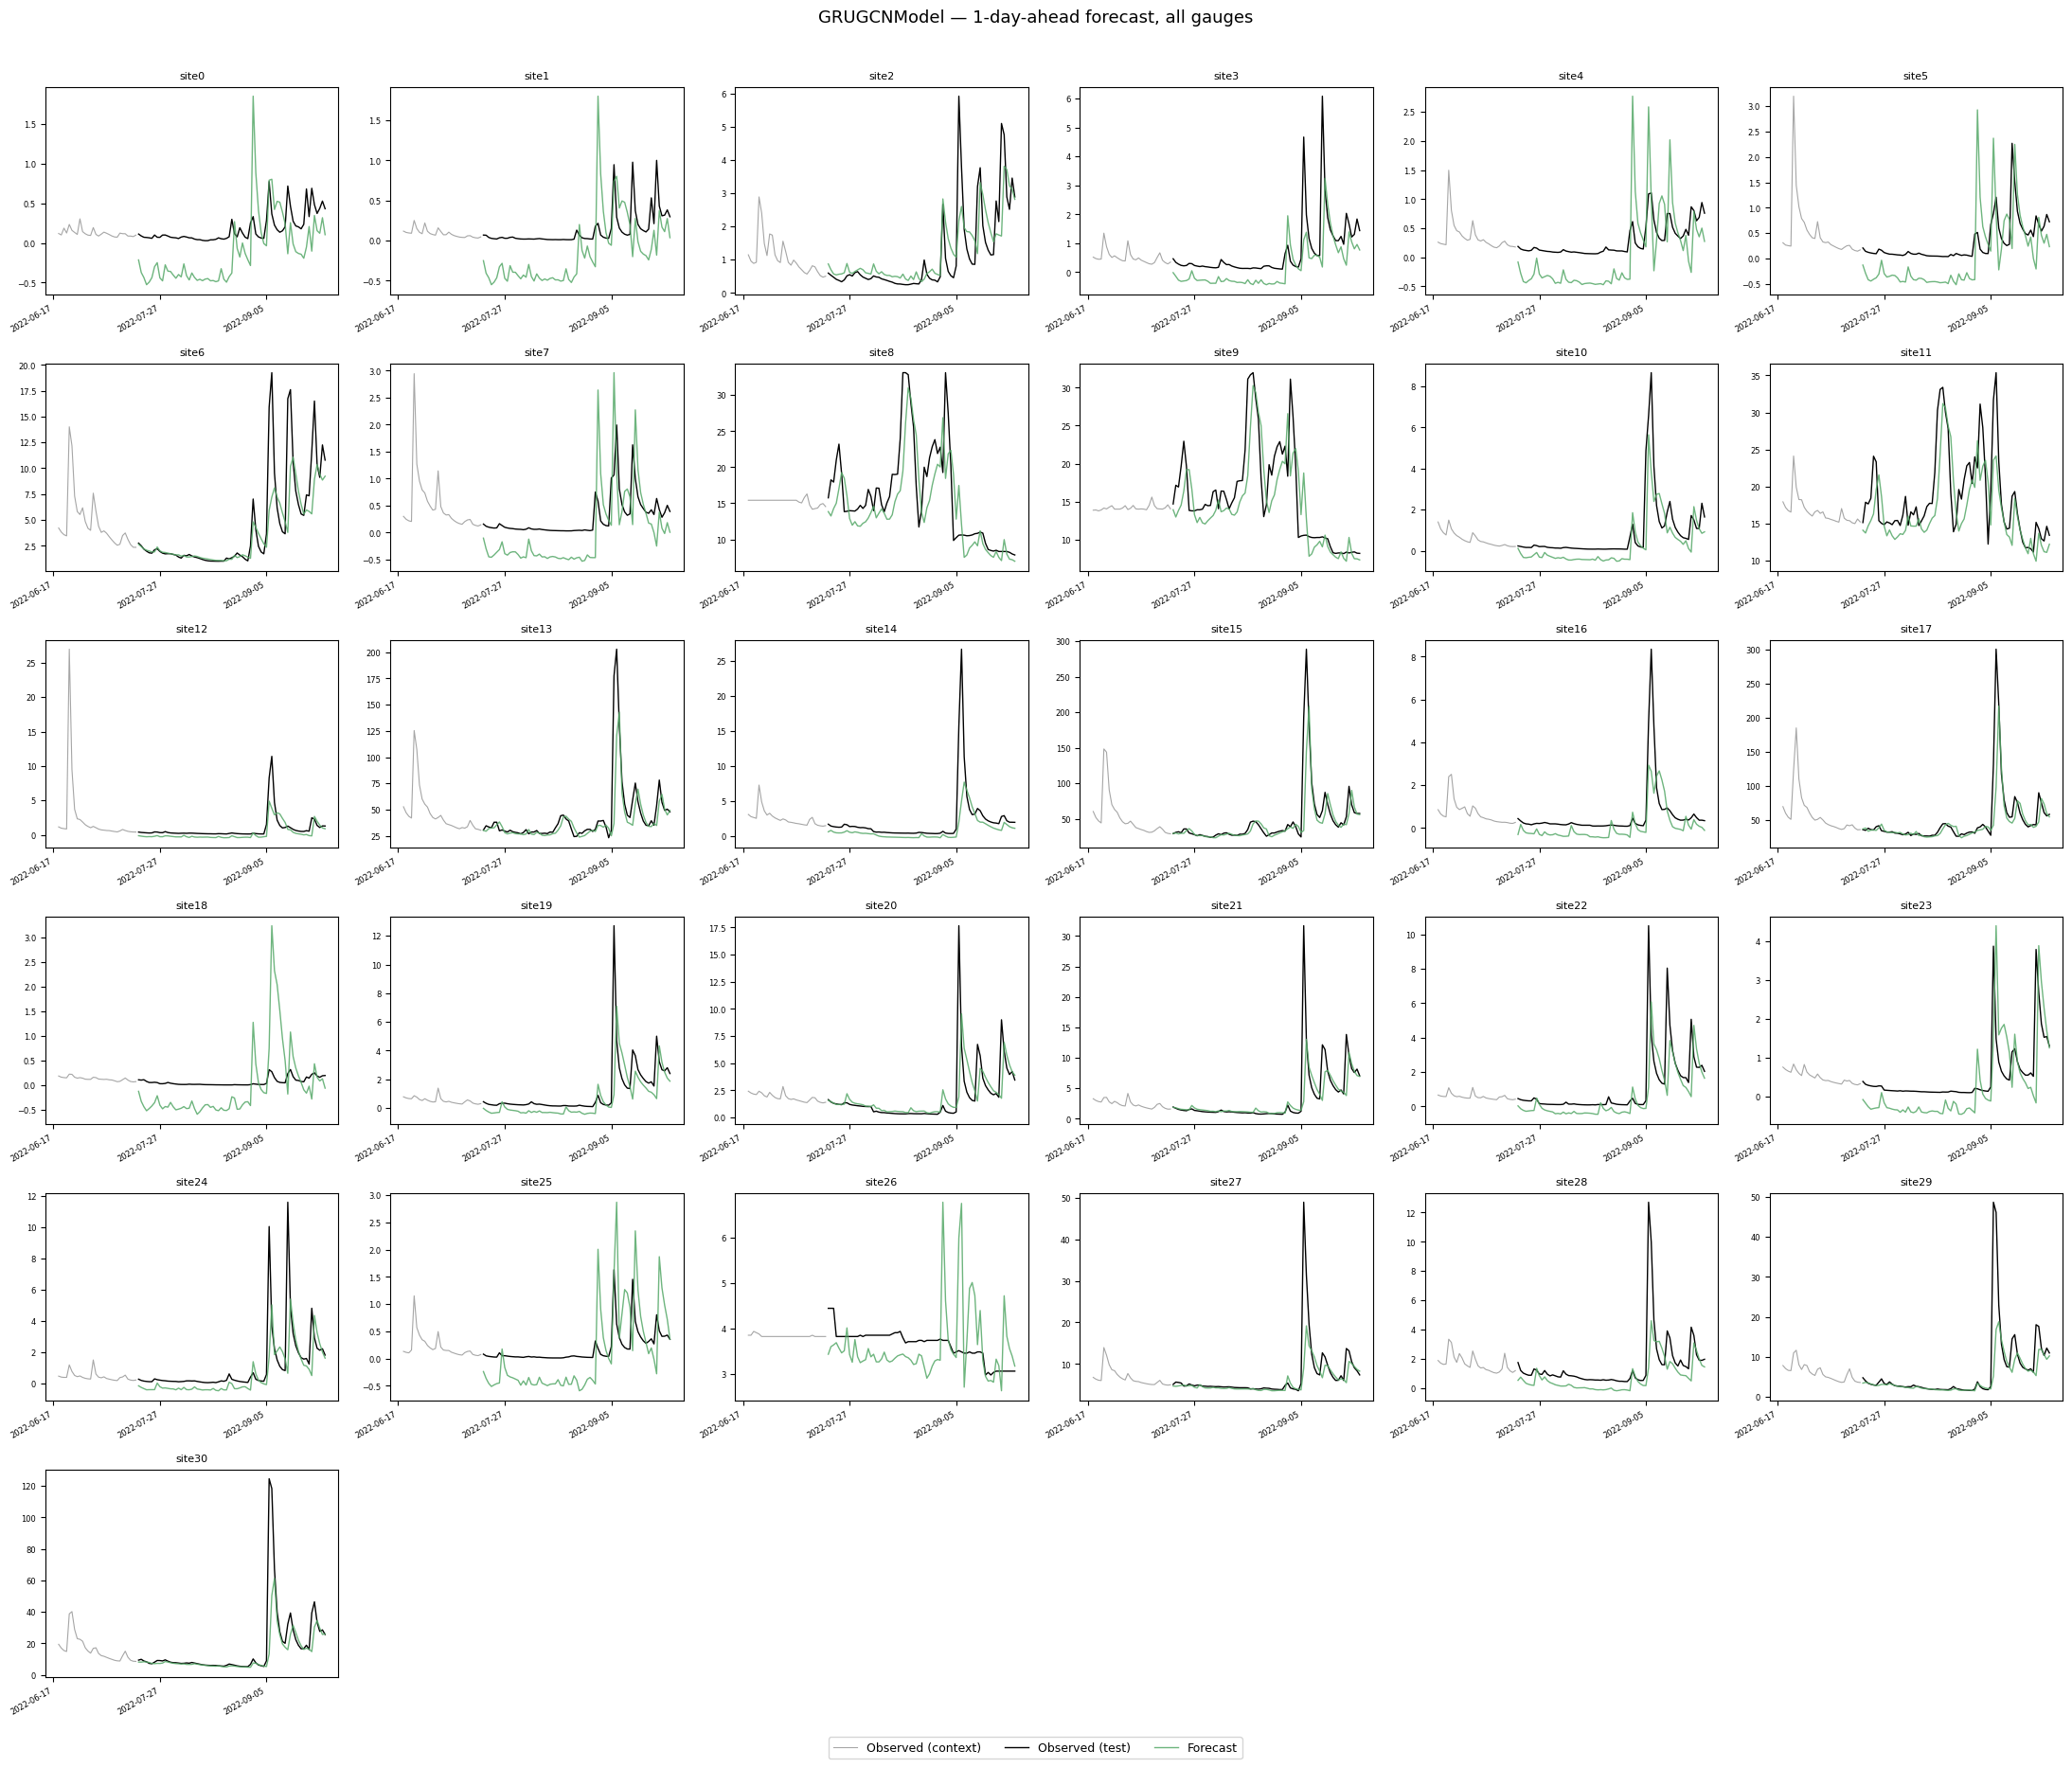

In [32]:
CONTEXT_DAYS = 30   # days of observed history to show before the test period
MODEL_COLORS = {'DCRNN': '#4C72B0', 'GRUGCNModel': '#55A868',
                'GraphWaveNet': '#C44E52', 'TransformerModel': '#8172B2'}

def plot_all_gauges(forecasts_dict, context_days=CONTEXT_DAYS):
    """
    For each model, plot all 31 gauges in a 6×6 grid.
    Shows context_days of observed history + full test period (truth vs forecast).
    """
    node_names = list(target.columns)   # site0 … site30
    ncols, nrows = 6, 6                 # 36 slots, last 5 left blank

    for model_name, fc in forecasts_dict.items():
        dates      = fc['dates']                     # DatetimeIndex, length n_test
        y_true     = fc['y_true']                    # (n_test, N)
        y_hat      = fc['y_hat']                     # (n_test, N)

        # Grab context from the target DataFrame
        test_start = dates[0]
        context_start = test_start - pd.Timedelta(days=context_days)
        context = target.loc[context_start:test_start - pd.Timedelta(days=1)]

        fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18), sharex=False)
        fig.suptitle(f'{model_name} — 1-day-ahead forecast, all gauges', fontsize=13, y=1.01)

        for idx, ax in enumerate(axes.flat):
            if idx >= N_NODES:
                ax.set_visible(False)
                continue

            # Context
            ax.plot(context.index, context.iloc[:, idx],
                    color='grey', lw=0.8, alpha=0.7, label='Observed (context)')
            # Ground truth during test period
            ax.plot(dates, y_true[:, idx],
                    color='black', lw=1.0, label='Observed (test)')
            # Forecast
            ax.plot(dates, y_hat[:, idx],
                    color=MODEL_COLORS[model_name], lw=1.0, alpha=0.85, label='Forecast')

            ax.set_title(node_names[idx], fontsize=8)
            ax.tick_params(labelsize=6)
            ax.xaxis.set_major_locator(plt.MaxNLocator(3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

        # Shared legend from the last visible axis
        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3,
                   fontsize=9, bbox_to_anchor=(0.5, -0.02))
        plt.tight_layout()
        plt.savefig(f"figures/all_sites_{model_name}_rain",dpi=300)
        plt.show()

plot_all_gauges(all_forecasts)

## 8. Outlet gauge — all models overlaid

site17 (`WEST BRANCH DELAWARE RIVER AT HOBART NY`) is the terminal node of the network
(no outgoing edges). This plot overlays all four model forecasts against the observed record,
with a longer context window to show seasonal patterns.

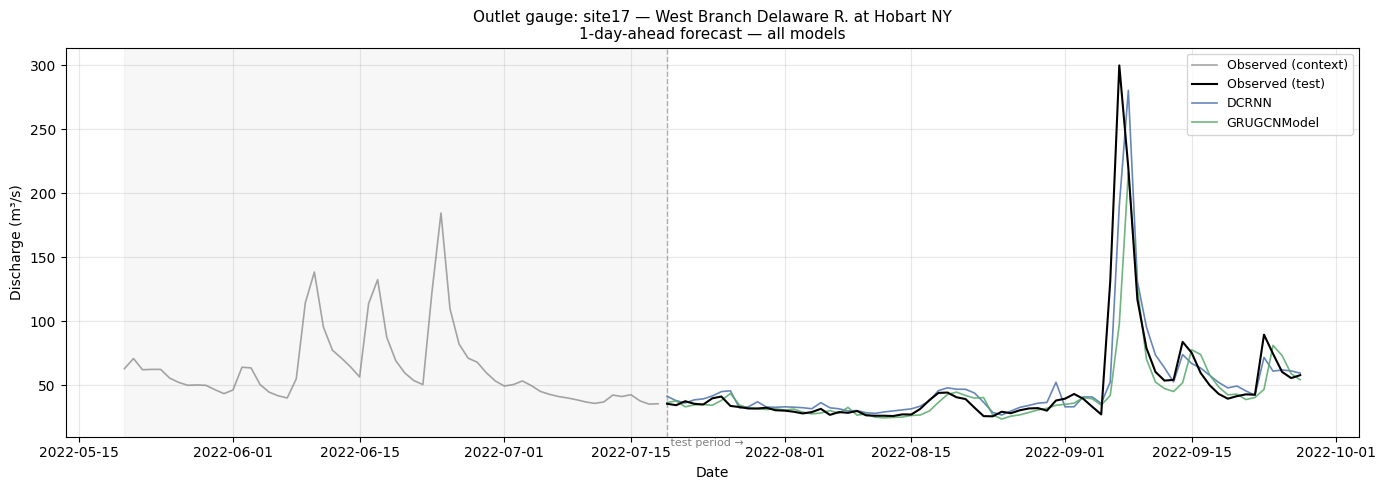

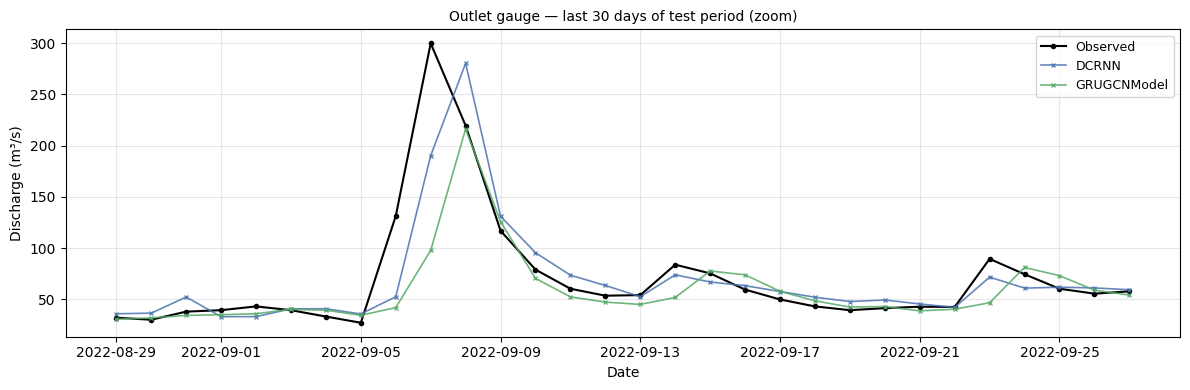

In [33]:
OUTLET_NODE  = 17          # site17 — terminal node (no outgoing edges)
OUTLET_NAME  = 'site17 — West Branch Delaware R. at Hobart NY'
CONTEXT_DAYS_OUTLET = 60   # longer window for the outlet plot

def plot_outlet(forecasts_dict, node_idx=OUTLET_NODE, context_days=CONTEXT_DAYS_OUTLET):
    """
    Single-panel plot of the outlet gauge: all models overlaid.
    Shows context_days of observed history + full test period.
    """
    # Use the first forecast dict to get dates (all models share the same test split)
    first_fc   = next(iter(forecasts_dict.values()))
    dates      = first_fc['dates']
    test_start = dates[0]

    context_start = test_start - pd.Timedelta(days=context_days)
    context = target.loc[context_start:test_start - pd.Timedelta(days=1), f'site{node_idx}']

    fig, ax = plt.subplots(figsize=(14, 5))

    # Shade the context vs test regions
    ax.axvspan(context.index[0], test_start, alpha=0.06, color='grey', label='_context region')
    ax.axvline(test_start, color='grey', lw=1, ls='--', alpha=0.6)
    ax.text(test_start, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 1,
            ' test period →', fontsize=8, color='grey', va='bottom')

    # Observed — context
    ax.plot(context.index, context.values,
            color='grey', lw=1.2, alpha=0.7, label='Observed (context)')

    # Observed — test period (from first forecast dict)
    ax.plot(dates, first_fc['y_true'][:, node_idx],
            color='black', lw=1.5, label='Observed (test)', zorder=5)

    # Each model forecast
    for model_name, fc in forecasts_dict.items():
        ax.plot(dates, fc['y_hat'][:, node_idx],
                color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85,
                label=f'{model_name}')

    ax.set_title(f'Outlet gauge: {OUTLET_NAME}\n1-day-ahead forecast — all models', fontsize=11)
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/all_forecasts_w_train_rain.png", dpi=300)
    plt.show()

    # ── Zoom: last 30 days of test period ────────────────────────────────
    zoom_start = dates[-30]
    mask = dates >= zoom_start

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(dates[mask], first_fc['y_true'][mask, node_idx],
             color='black', lw=1.5, marker='o', ms=3, label='Observed')

    for model_name, fc in forecasts_dict.items():
        ax2.plot(dates[mask], fc['y_hat'][mask, node_idx],
                 color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85,
                 marker='x', ms=3, label=model_name)

    ax2.set_title(f'Outlet gauge — last 30 days of test period (zoom)', fontsize=10)
    ax2.set_ylabel('Discharge (m³/s)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/all_forecasts_rain.png", dpi=300)
    plt.show()

plot_outlet(all_forecasts)

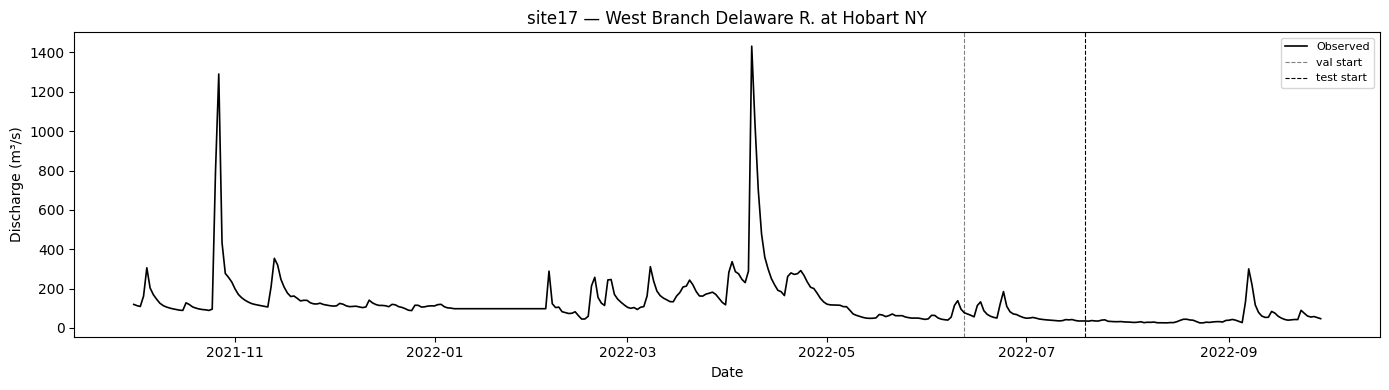

In [34]:
NODE = 17                                                                                                                         
NODE_NAME = 'site17 — West Branch Delaware R. at Hobart NY'
                                                                                                                                
fig, ax = plt.subplots(figsize=(14, 4))                                                                                           
                                                                                                                                
# Full observed water year                                                                                                        
ax.plot(target.index, target[f'site{NODE}'],
      color='black', linewidth=1.2, label='Observed', zorder=3)                                                                 
                                                                                                                                
# Overlay each model's step-1 forecast for the test period                                                                        
# for name, fc in forecasts_dict.items():                                                                                           
#   ax.plot(fc['dates'], fc['y_hat'][:, NODE],
#           color=MODEL_COLORS[name], linewidth=1.0,                                                                              
#           alpha=0.8, label=name)
                                                                                                                                
# Mark train/val/test boundaries                                                                                                  
# dm_ref = next(iter(forecasts_dict.values()))['dm']
val_start  = target.index[int(len(target) * 0.70)]                                                                                
test_start = target.index[int(len(target) * 0.80)]                                                                                
ax.axvline(val_start,  color='grey',  linestyle='--', linewidth=0.8, label='val start')                                           
ax.axvline(test_start, color='black', linestyle='--', linewidth=0.8, label='test start')                                          
              
ax.set_title(NODE_NAME)                                                                                                           
ax.set_ylabel('Discharge (m³/s)')
ax.set_xlabel('Date')                                                                                                             
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()                                                                                                                
plt.savefig('figures/hydrograph_site17_full_wy.png', dpi=300)
plt.show()

## 9. Per-site error analysis — upstream vs downstream

Two panels:
- **Absolute MAE (m³/s)** — shows which sites have the largest raw error.
- **Relative MAE (% of mean observed discharge)** — normalises by site size so small
  headwater gauges aren't penalised for having low discharge.

Sites are ordered from 0 to 30, with the outlet (site 17) denoted.  If the GNN spatial aggregation helps, we would expect
**error to decrease as we move downstream**, because downstream nodes receive
informative graph messages from all upstream neighbours.

**We see that the relative MAE is in fact higher at the most upstream outlets (site 0-1 and site 18), however there is not such a clear decrease otherwise. The absolute error is still bigger downstream as there is generally more flow as you move down the river network/graph.**


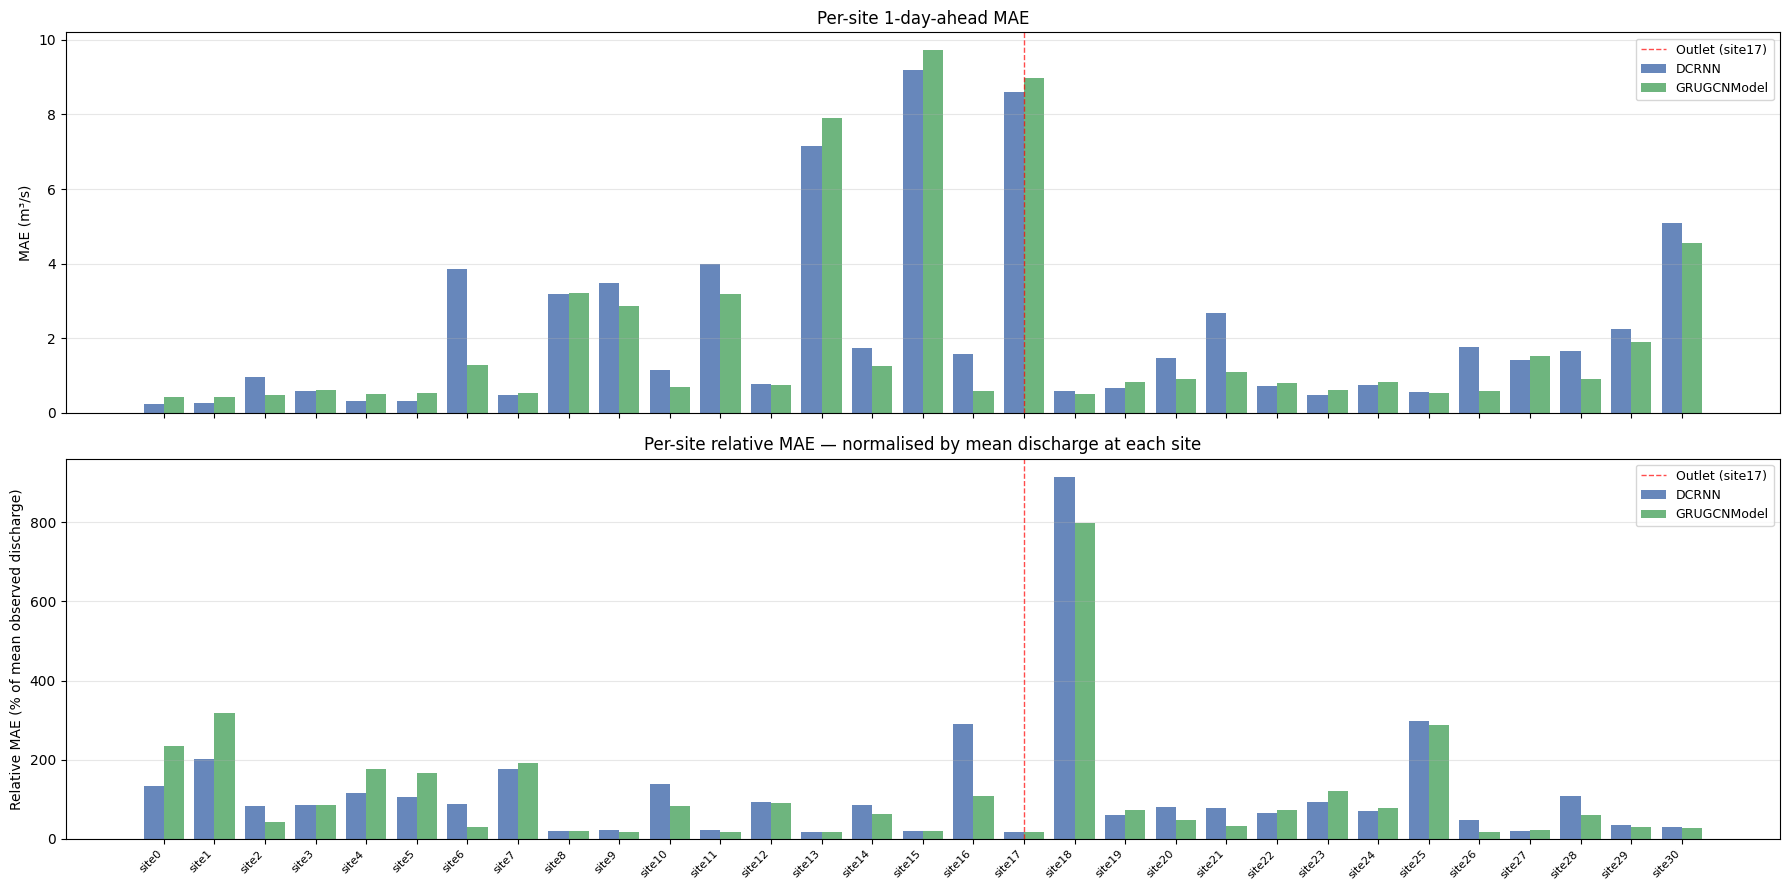

In [35]:


# ── Per-site MAE bar chart (site0 → site30) ────────────────────────────
site_indices = list(range(N_NODES))
x_labels     = [f'site{n}' for n in site_indices]
n_models     = len(all_forecasts)
bar_width    = 0.8 / n_models
x            = np.arange(N_NODES)

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

# Panel 1: absolute MAE
ax1 = axes[0]
for i, (model_name, fc) in enumerate(all_forecasts.items()):
    per_site_mae = np.abs(fc['y_true'] - fc['y_hat']).mean(axis=0)  # (N,)
    offsets = (i - (n_models - 1) / 2) * bar_width
    ax1.bar(x + offsets, per_site_mae[site_indices],
            width=bar_width, label=model_name,
            color=MODEL_COLORS[model_name], alpha=0.85)

ax1.axvline(OUTLET_NODE, color='red', ls='--', lw=1.0, alpha=0.7, label='Outlet (site17)')
ax1.set_ylabel('MAE (m³/s)')
ax1.set_title('Per-site 1-day-ahead MAE')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: relative MAE normalised by mean observed discharge
ax2 = axes[1]
for i, (model_name, fc) in enumerate(all_forecasts.items()):
    per_site_mae  = np.abs(fc['y_true'] - fc['y_hat']).mean(axis=0)
    per_site_mean = fc['y_true'].mean(axis=0).clip(min=0.01)
    per_site_rel  = per_site_mae / per_site_mean * 100
    offsets = (i - (n_models - 1) / 2) * bar_width
    ax2.bar(x + offsets, per_site_rel[site_indices],
            width=bar_width, label=model_name,
            color=MODEL_COLORS[model_name], alpha=0.85)

ax2.axvline(OUTLET_NODE, color='red', ls='--', lw=1.0, alpha=0.7, label='Outlet (site17)')
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Relative MAE (% of mean observed discharge)')
ax2.set_title('Per-site relative MAE — normalised by mean discharge at each site')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/per_site_mae_by_position.png', dpi=300)
plt.show()


The **persistence diagnostic** printed below checks whether the model is essentially
learning `Q̂(t+1) ≈ Q(t)` (i.e. today's value as tomorrow's forecast). 

We wanted to investigate this since our peaks seem always exactly one day lagged. However, we see that in fact the correlation is higher between what is predicted and observed at time t, then 

In [36]:
# ── Persistence diagnostic at the outlet ──────────────────────────────
print('Outlet (site17) — persistence vs model:')
for model_name, fc in all_forecasts.items():
    yt = fc['y_true'][:, OUTLET_NODE]
    yh = fc['y_hat'][:, OUTLET_NODE]
    persist_mae = float(np.abs(np.diff(yt)).mean())
    model_mae   = float(np.abs(yt - yh).mean())
    corr_same   = float(np.corrcoef(yh, yt)[0, 1])
    # corr_lag1   = float(np.corrcoef(yh[:-1], yt[1:])[0, 1])
    corr_lag1   = float(np.corrcoef(yh[1:], yt[:-1])[0, 1])
    print(f'  {model_name}: model_MAE={model_mae:.3f}  persist_MAE={persist_mae:.3f}  '
          f'corr(ŷ,y)={corr_same:.3f}  corr(ŷₜ,yₜ-₁)={corr_lag1:.3f}')

Outlet (site17) — persistence vs model:
  DCRNN: model_MAE=8.610  persist_MAE=11.453  corr(ŷ,y)=0.894  corr(ŷₜ,yₜ-₁)=0.932
  GRUGCNModel: model_MAE=8.984  persist_MAE=11.453  corr(ŷ,y)=0.772  corr(ŷₜ,yₜ-₁)=0.974


## 10. Horizon comparison and lagged ensemble at the outlet -- Justification for using 1 day ahead prediction

For each model, plot all three horizon steps at their **target dates** alongside the
lagged ensemble:

| Line | Made using data up to… | Predicts… |
|------|------------------------|----------|
| step-1 | yesterday | today |
| step-2 | two days ago | today |
| step-3 | three days ago | today |
| ensemble | all three averaged | today |

**We see that the prediction based on most recent information is best, and that the "delay" in predicting peaks increases as we predict from further out.**


DCRNN — outlet MAE by horizon:
  step-1:   8.610 m³/s
  step-2:   15.320 m³/s
  step-3:   20.029 m³/s
  ensemble: 13.934 m³/s


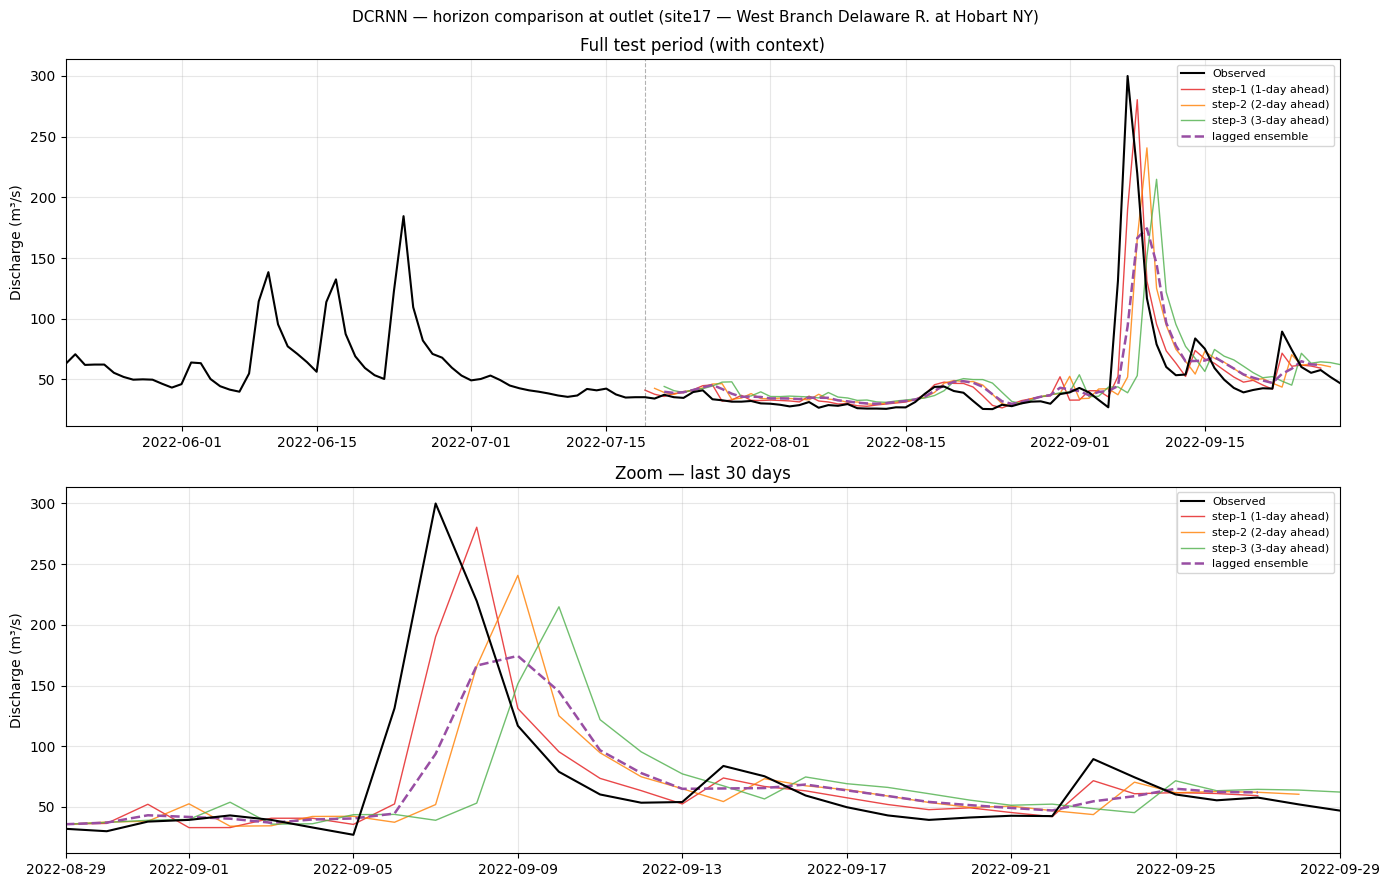


GRUGCNModel — outlet MAE by horizon:
  step-1:   8.984 m³/s
  step-2:   15.003 m³/s
  step-3:   18.171 m³/s
  ensemble: 13.128 m³/s


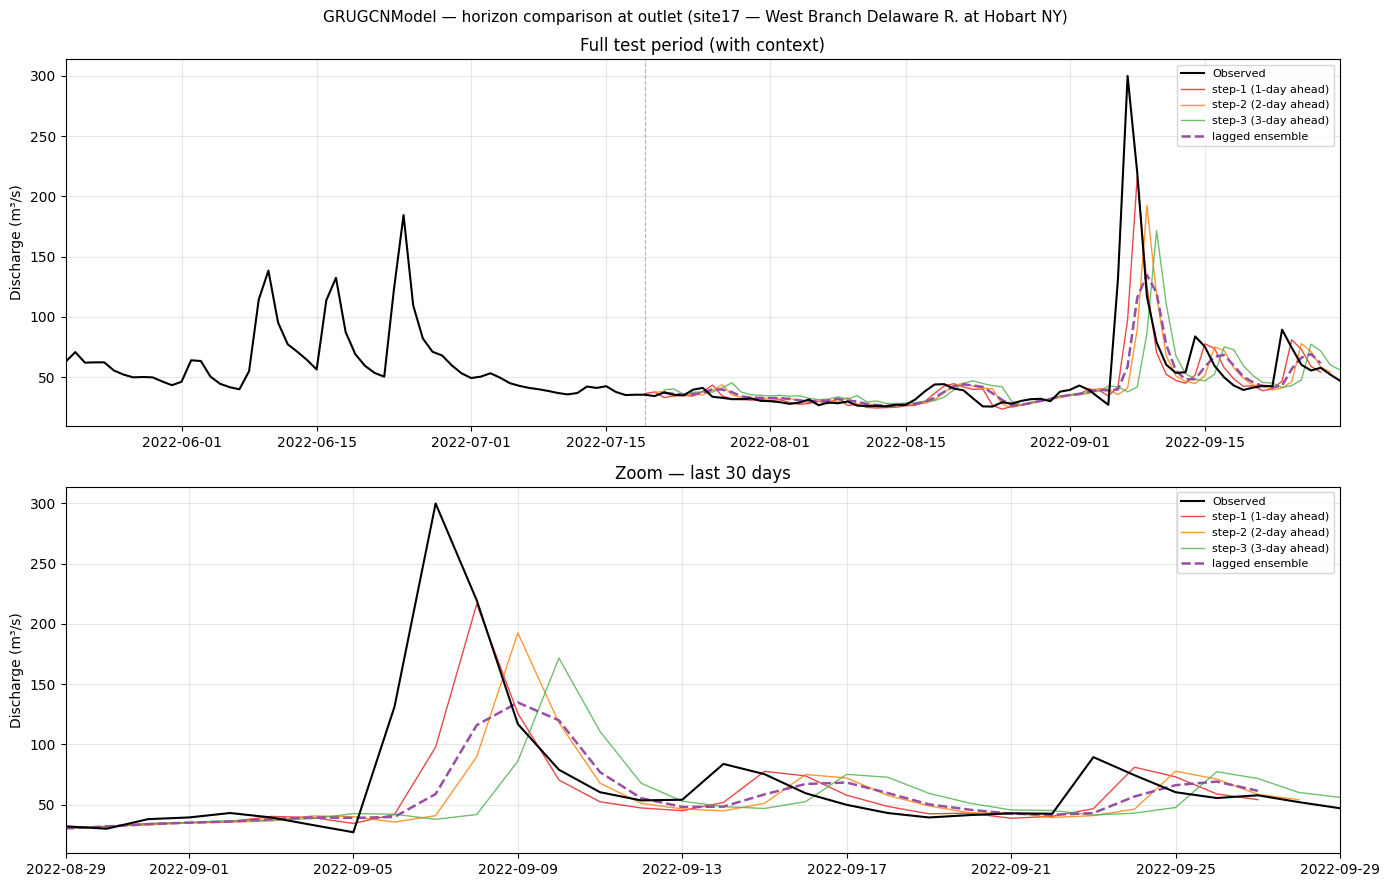

In [37]:
NODE = OUTLET_NODE

H_STYLES = {
    'step-1 (1-day ahead)': dict(color='#e41a1c', lw=1.0, alpha=0.8, ls='-'),
    'step-2 (2-day ahead)': dict(color='#ff7f00', lw=1.0, alpha=0.8, ls='-'),
    'step-3 (3-day ahead)': dict(color='#4daf4a', lw=1.0, alpha=0.8, ls='-'),
    'lagged ensemble':       dict(color='#984ea3', lw=1.8, alpha=1.0, ls='--'),
}

for model_name, fc in all_forecasts.items():
    y_hat_h  = fc['y_hat_h']   # (n_test, 3, N)
    y_true_h = fc['y_true_h']  # (n_test, 3, N)
    dates    = fc['dates']     # DatetimeIndex, n_test entries

    # Each horizon step plotted at its target date
    d1, yh1, yt1 = dates,                       y_hat_h[:, 0, NODE], y_true_h[:, 0, NODE]
    d2, yh2, yt2 = dates + pd.Timedelta('1d'),  y_hat_h[:, 1, NODE], y_true_h[:, 1, NODE]
    d3, yh3, yt3 = dates + pd.Timedelta('2d'),  y_hat_h[:, 2, NODE], y_true_h[:, 2, NODE]

    # Lagged ensemble: for dates[2:], average all three predictions for the same target date
    ens_dates = dates[2:]
    ens_yh    = (y_hat_h[2:, 0, NODE] + y_hat_h[1:-1, 1, NODE] + y_hat_h[:-2, 2, NODE]) / 3
    ens_yt    = y_true_h[2:, 0, NODE]

    print(f'\n{model_name} — outlet MAE by horizon:')
    print(f'  step-1:   {np.abs(yh1 - yt1).mean():.3f} m³/s')
    print(f'  step-2:   {np.abs(yh2 - yt2).mean():.3f} m³/s')
    print(f'  step-3:   {np.abs(yh3 - yt3).mean():.3f} m³/s')
    print(f'  ensemble: {np.abs(ens_yh - ens_yt).mean():.3f} m³/s')

    # Observed from target DataFrame covering context + all target dates
    obs = target.loc[
        dates[0] - pd.Timedelta(days=CONTEXT_DAYS_OUTLET) : d3[-1],
        f'site{NODE}'
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    fig.suptitle(f'{model_name} — horizon comparison at outlet ({OUTLET_NAME})', fontsize=11)

    for ax in axes:
        ax.plot(obs.index, obs.values, color='black', lw=1.5, label='Observed', zorder=5)
        ax.plot(d1, yh1, label='step-1 (1-day ahead)', **H_STYLES['step-1 (1-day ahead)'])
        ax.plot(d2, yh2, label='step-2 (2-day ahead)', **H_STYLES['step-2 (2-day ahead)'])
        ax.plot(d3, yh3, label='step-3 (3-day ahead)', **H_STYLES['step-3 (3-day ahead)'])
        ax.plot(ens_dates, ens_yh, label='lagged ensemble', **H_STYLES['lagged ensemble'])
        ax.set_ylabel('Discharge (m³/s)')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)

    axes[0].set_xlim(dates[0] - pd.Timedelta(days=CONTEXT_DAYS_OUTLET), d3[-1])
    axes[0].set_title('Full test period (with context)')
    axes[0].axvline(dates[0], color='grey', ls='--', lw=0.8, alpha=0.6)

    axes[1].set_xlim(dates[-30], d3[-1])
    axes[1].set_title('Zoom — last 30 days')

    plt.tight_layout()
    plt.savefig(f'figures/horizon_comparison_{model_name}.png', dpi=300)
    plt.show()